# Exact-exchange optimized effective potential method

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  10/07/2025  
**Last modified:**  20/08/2026

## 1. Introduction

In this tutorial, I will present examples of self-consistent exact-exhange (EXX) optimized effective potential (OEP) calculations. These examples are intended to illustrate the main functionality and post-processing of calculations, such as plotting of resulting exchange potentials, accessing eigenvalues, etc.

---

The approach used in the present implementation of the EXX-OEP code was introduced in
> A. Görling. New KS Method for Molecules Based on an Exchange Charge Density Generating the Exact Local KS Exchange Potential - Phys. Rev. Lett. 83, 5459 (1999). [link](https://doi.org/10.1103/PhysRevLett.83.5459)

The original implementation in Molpro was described in

> A. Heßelmann, A.W. Götz, F. Della Sala, A. Görling. Numerically stable optimized effective potential method with balanced Gaussian basis sets - J. Chem. Phys. 127, 054102 (2007). [link](https://doi.org/10.1063/1.2751159)

The current implementation with new basis set preprocessing for OEP basis and options to symmetrize EXX-OEP in real, spin or both real and spin space is described in the following publications:

> E. Trushin, A. Görling. Numerically stable optimized effective potential method with standard Gaussian basis sets - J. Chem. Phys. 155 (2021) 054109. [link](https://doi.org/10.1063/5.0056431)  
> E. Trushin, A. Görling. Avoiding spin contamination and spatial symmetry breaking by exact-exchange-only optimized-effective-potential methods within the symmetrized Kohn-Sham framework - J. Chem. Phys. 159 (2023) 244109. [link](https://doi.org/10.1063/5.0171546)

---

<div class="alert alert-block alert-info"> <b>Important:</b> Read carefully the information below about the selection of basis sets and the thr_fai_oep parameter. </div>

EXX-OEP calculations requires to specify two basis sets, namely orbital and OEP basis sets. If density fitting is employed, the corresponding basis sets have to be also specified. The orbital basis set is the primary basis set for e.g. the representation of orbitals and the calculation of energy contributions. The OEP basis set is the auxiliary basis set for representing e.g. the exchange potential. 
Gaussian basis set OEP methods for a long time suffered from numerical instabilities resulting from problems in balancing the orbital basis sets with the auxiliary basis sets.
Present implementation uses a preprocessing of the auxiliary basis that enables such balancing in an automatic fashion for standard Gaussian basis sets.
The preprocessing step removes linear combinations of auxiliary basis functions that couple poorly to products of occupied times unoccupied Kohn-Sham orbitals. It involves the threshold `thr_fai_oep`, which determines how many linear combinations of auxiliary basis functions are removed and varies with respect to the size of the orbital basis set used. This scheme was tested using Dunning correlation consistent basis sets aug-cc-pwCVXZ (X = T, Q, 5) and recommended thresholds are

| Orbital basis set | **thr_fai_oep** |
| :----: | :----: |
| aug-cc-pwCVTZ  | $5 \cdot 10^{-2}$   |
| aug-cc-pwCVQZ  | $1.7 \cdot 10^{-2}$ |
| aug-cc-pwCV5Z  | $5 \cdot 10^{-3}$   |

These thresholds are also expected to work for orbital basis sets without augmentation cc-pwCVXZ (X = T, Q, 5) and without core-polarization functions aug-cc-pVXZ (X = T, Q, 5).

As an auxiliary basis set (OEP), the aug-cc-pVXZ/mp2fit (X=T,Q,5) family of basis sets is recommended. In particular, it is recommended to use the aug-cc-pVDZ/mp2fit auxiliary basis sets for atoms up to neon and the aug-cc-pVTZ/mp2fit auxiliary basis sets for heavier atoms.

Def2 basis sets of Ahlrichs family of similar quality also might work, but were not tested extensively in practice.

---

Let's start with the import of the required libraries and functions.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from pyscf import dft, gto, scf

from methods.exxoep import EXXOEP
from methods.osexxoep import OSEXXOEP
from utils.coulomb_potential_on_grid import coulomb_potential_on_grid
from utils.gen_coords_1d import gen_coords_1d

matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.figsize"] = (5, 4)

## 2. Calculations for closed-shell systems

### 2.1 CO molecule
We start with the EXX-OEP calculation of the closed-shell molecule, CO. We will plot the resulting exchange potentials along the bond axis, including its reference and reminder parts. 

In [2]:
# basis sets, to be used for all systems
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"

# geometry
GEOM = "C 0.000000    0.000000   -0.646514; O 0.000000    0.000000    0.484886"

# create mol object
mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False

In [3]:
# run Hartree-Fock calculation
mf = scf.RHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = EXXOEP(mf, OEP_BASIS)
mf_oep.run(maxit=15, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0   -112.782740581670
  1   -112.782779314437     -0.000038732766
  2   -112.782834855646     -0.000055541209
  3   -112.782857949449     -0.000023093803
  4   -112.782858257143     -0.000000307694
  5   -112.782858318460     -0.000000061317
  6   -112.782858317194      0.000000001265
SCF converged


In the end, we have the access to the reference $v_x^{ref}$, rest $v_x^{rest}$ and full $v_x$ exchange potentials. Let's plot the potentials.

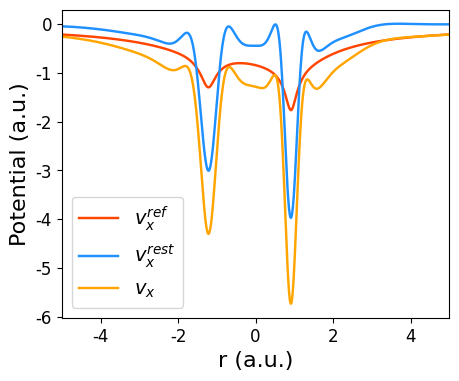

In [4]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vrest_on_grid = vcoul_on_grid @ mf_oep.vrest_oep
vref_on_grid = vcoul_on_grid @ mf_oep.vref_oep
vx_on_grid = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vref_oep)

plt.plot(coords[:, 2], vref_on_grid, color="orangered", label="$v_{x}^{ref}$")
plt.plot(coords[:, 2], vrest_on_grid, color="dodgerblue", label="$v_{x}^{rest}$")
plt.plot(coords[:, 2], vx_on_grid, color="orange", label="$v_x$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

Let's print eigenvalues, HOMO energy, and LUMO-HOMO gap.

In [5]:
# Function to make text in bold
def bold_text(text):
    return "\033[1m" + text + "\033[0m"


def print_eigs(eigs, no, nmax):
    """Function to print eigenvalues, HOMO energy, and LUMO-HOMO gap.

    Args:
      eig: Eigenvalues.
      no: Number of occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    if len(eigs.shape) == 1:  # closed-shell case
        for i in range(nmax):
            eig = f"{eigs[i]:7.3f}"
            if i + 1 <= no:
                eig = bold_text(eig)
            print(f"{i + 1:2}   {eig}")
        print(f"HOMO:      {eigs[no - 1]:7.3f}")
        print(f"LUMO-HOMO: {eigs[no] - eigs[no - 1]:7.3f}")
    else:
        for i in range(nmax):
            ea = f"{eigs[0, i]:7.3f}"
            eb = f"{eigs[1, i]:7.3f}"
            if i + 1 <= no[0]:
                ea = bold_text(ea)
            if i + 1 <= no[1]:
                eb = bold_text(eb)
            if i + 1 <= nmax:
                print(f"{i + 1:2}   {ea}  {eb}")
        print(f"HOMO:       {eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1] - 1]:7.3f}")
        print(f"LUMO-HOMO:  {eigs[0, no[0]] - eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1]] - eigs[1, no[1] - 1]:7.3f}")

In [6]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 10)

 1   -18.989
 2   -10.172
 3    -1.256
 4    -0.685
 5    -0.588
 6    -0.588
 7    -0.481
 8    -0.198
 9    -0.198
10    -0.115
HOMO:       -0.481
LUMO-HOMO:   0.282


Eigenvalues corresponding to occupied orbitals are printed in bold.

We can also access the resulting total energy:

In [7]:
print("Total energy:", mf_oep.e_tot)

Total energy: -112.7828583171943


### 2.2 CO molecule with HOMO condition
We can enforce an additional exact condition for the exchange potential, the so-called HOMO condition:
$$<\varphi_{HOMO}|v_x|\varphi_{HOMO}> = <\varphi_{HOMO}|\hat{v}_x^{NL}|\varphi_{HOMO}>$$
where $v_x$ is local exchange potential, $\hat{v}_x^{NL}$ is non-local exchange operator, and $\varphi_{HOMO}$ is is the HOMO of the Kohn-Sham system.  
Enforcing this condition typically leads to EXX HOMO energy close to Hartree-Fock HOMO energy.

In [8]:
# run Hartree-Fock calculation
mf = scf.RHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation with HOMO condition
mf_oep = EXXOEP(mf, OEP_BASIS, use_HOMO_condition=True)
mf_oep.run(maxit=15, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0   -112.782941229600
  1   -112.782975613398     -0.000034383798
  2   -112.782976693363     -0.000001079964
  3   -112.783034012080     -0.000057318717
  4   -112.783033987704      0.000000024375
  5   -112.783034055901     -0.000000068197
  6   -112.783034057979     -0.000000002078
SCF converged


In [9]:
print_eigs(mf_oep.mf.mo_energy, 7, 10)

 1   -19.069
 2   -10.242
 3    -1.330
 4    -0.759
 5    -0.663
 6    -0.663
 7    -0.554
 8    -0.270
 9    -0.270
10    -0.154
HOMO:       -0.554
LUMO-HOMO:   0.283


As might be seen, the HOMO energy is shifted as well as other eigenvalues.

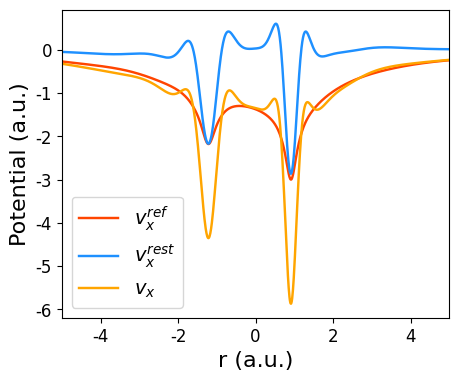

In [10]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vrest_on_grid = vcoul_on_grid @ mf_oep.vrest_oep
vref_on_grid = vcoul_on_grid @ mf_oep.vref_oep
vx_on_grid = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vref_oep)

plt.plot(coords[:, 2], vref_on_grid, color="orangered", label="$v_{x}^{ref}$")
plt.plot(coords[:, 2], vrest_on_grid, color="dodgerblue", label="$v_{x}^{rest}$")
plt.plot(coords[:, 2], vx_on_grid, color="orange", label="$v_x$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

In [11]:
print("Total energy:", mf_oep.e_tot)

Total energy: -112.78303405797942


The exchange potential of the EXX-OEP method possesses correct $-1/r$ asymptotic decay, in contrast to the commonly used (semi-)local functionals. Let's compare the EXX-OEP exchange potential with the exchange-correlation potential from an LDA calculation.

In [12]:
coords = gen_coords_1d(-10.0, 10.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vx_on_grid = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vref_oep)

In [13]:
mf = dft.RKS(mol, xc="LDA_X, LDA_C_VWN_RPA").density_fit().run(conv_tol=1e-14)
dm = mf.make_rdm1()
ao_value = dft.numint.eval_ao(mol, coords, deriv=0)
rho = dft.numint.eval_rho(mol, ao_value, dm, xctype="LDA")
_, vxc_lda = dft.libxc.eval_xc("LDA_X, LDA_C_VWN_RPA", rho)[:2]

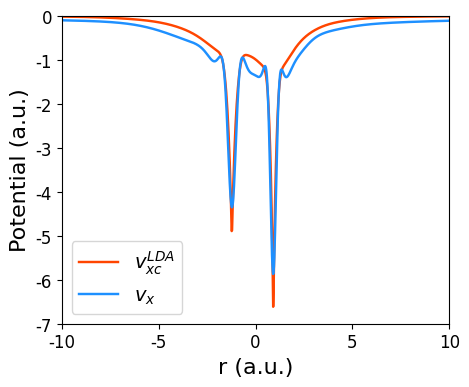

In [14]:
plt.plot(coords[:, 2], vxc_lda[0], color="orangered", label="$v_{xc}^{LDA}$")
plt.plot(coords[:, 2], vx_on_grid, color="dodgerblue", label="$v_x$")
plt.xlim(-10, 10)
plt.ylim(-7, 0.01)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

## 3. Calculations for open-shell systems

### 3.1 Spin-unrestricted calculation for N atom
A common way to perform Kohn-Sham (KS) calculations for open-shell systems is based on the spin-unrestricted KS method, which uses two different sets of spatial orbitals for $\alpha$ and $\beta$ electrons. This leads to two different effective KS potentials for the $\alpha$- and $\beta$-electrons.

In [15]:
# geomerty
GEOM = "N 0.000000    0.000000  0.000000"

# create mol object
mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=3)
mol.verbose = 0
mol.symmetry = False

In [16]:
# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -54.402595342261
  1    -54.402598236289     -0.000002894028
  2    -54.402598262750     -0.000000026461
  3    -54.402598327132     -0.000000064382
  4    -54.402598326010      0.000000001121
SCF converged


In [17]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -14.310  -14.418
 2    -0.972   -0.732
 3    -0.533   -0.323
 4    -0.533   -0.323
 5    -0.533   -0.323
 6    -0.128   -0.109
 7    -0.081   -0.065
HOMO:        -0.533    -0.732
LUMO-HOMO:    0.405     0.409


The electron configuration of N in its ground state is $1s^22s^22p^3$. There are five $\alpha$ occupied orbitals and two $\beta$ occupied orbital. Due to spin symmetry breaking, there are two spin channels with spatially different $\alpha$ and $\beta$ orbitals with different energies. Orbital energies for $\alpha$ and $\beta$ spin channels differ, reflecting spin symmetry breaking, whereas they are the same in a real electronic system.  
Spin contamination appears, as can be seen from the values of the $S^2$ operator deviating from the correct value of 3.75.

In [18]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 3.7573699


Spin symmetry breaking leads to different exchange potentials for $\alpha$ and $\beta$ spin channels.

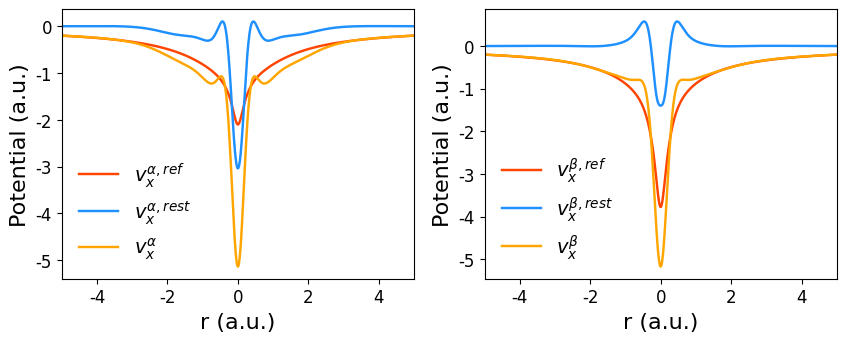

In [19]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vrest_on_grid_a = vcoul_on_grid @ mf_oep.vrest_oep_a
vref_on_grid_a = vcoul_on_grid @ mf_oep.vref_oep_a
vx_on_grid_a = vcoul_on_grid @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vrest_on_grid_b = vcoul_on_grid @ mf_oep.vrest_oep_b
vref_on_grid_b = vcoul_on_grid @ mf_oep.vref_oep_b
vx_on_grid_b = vcoul_on_grid @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords[:, 2], vref_on_grid_a, color="orangered", label="$v_{x}^{\\alpha, ref}$")
axs[0].plot(coords[:, 2], vrest_on_grid_a, color="dodgerblue", label="$v_{x}^{\\alpha, rest}$")
axs[0].plot(coords[:, 2], vx_on_grid_a, color="orange", label="$v_x^{\\alpha}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords[:, 2], vref_on_grid_b, color="orangered", label="$v_{x}^{\\beta, ref}$")
axs[1].plot(coords[:, 2], vrest_on_grid_b, color="dodgerblue", label="$v_{x}^{\\beta, rest}$")
axs[1].plot(coords[:, 2], vx_on_grid_b, color="orange", label="$v_x^{\\beta}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.2 Spin-restricted calculation for N atom

An alternative approach to the spin-unrestricted KS method is to use one set of spatial orbitals for electrons of both spins. This approach is often referred to as the spin-restricted KS method for open-shell systems. 

In [20]:
# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

mf_oep = OSEXXOEP(mf, OEP_BASIS, spin_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -54.397093795674
  1    -54.397319092022     -0.000225296348
  2    -54.397360123276     -0.000041031254
  3    -54.397360382871     -0.000000259595
  4    -54.397360473378     -0.000000090507
  5    -54.397360474845     -0.000000001467
SCF converged


In [21]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -14.398  -14.398
 2    -0.948   -0.948
 3    -0.513   -0.513
 4    -0.513   -0.513
 5    -0.513   -0.513
 6    -0.125   -0.125
 7    -0.079   -0.079
HOMO:        -0.513    -0.948
LUMO-HOMO:    0.387     0.435


In contrast to the spin-unrestricted case, the spin-restricted calculation does not exhibit spin symmetry breaking leading to the same orbital energies in $\alpha$ and $\beta$ spin channels.

In [22]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 3.7500000


The potentials of $\alpha$ and $\beta$ are the same or in other words $\alpha$ and $\beta$ electrons move in the same potential.

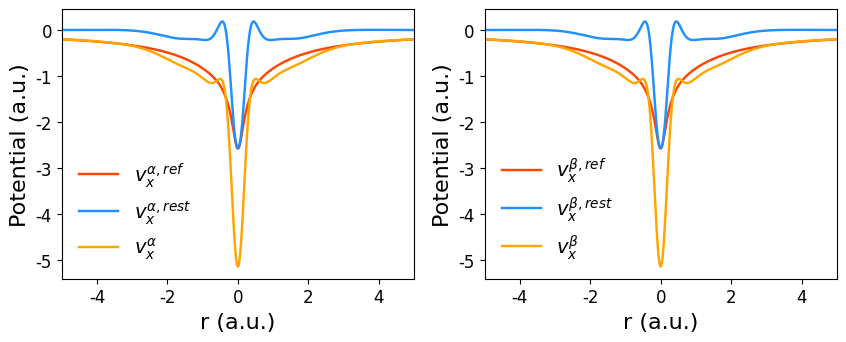

In [23]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vrest_on_grid_a = vcoul_on_grid @ mf_oep.vrest_oep_a
vref_on_grid_a = vcoul_on_grid @ mf_oep.vref_oep_a
vx_on_grid_a = vcoul_on_grid @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vrest_on_grid_b = vcoul_on_grid @ mf_oep.vrest_oep_b
vref_on_grid_b = vcoul_on_grid @ mf_oep.vref_oep_b
vx_on_grid_b = vcoul_on_grid @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords[:, 2], vref_on_grid_a, color="orangered", label="$v_{x}^{\\alpha, ref}$")
axs[0].plot(coords[:, 2], vrest_on_grid_a, color="dodgerblue", label="$v_{x}^{\\alpha, rest}$")
axs[0].plot(coords[:, 2], vx_on_grid_a, color="orange", label="$v_x^{\\alpha}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords[:, 2], vref_on_grid_b, color="orangered", label="$v_{x}^{\\beta, ref}$")
axs[1].plot(coords[:, 2], vrest_on_grid_b, color="dodgerblue", label="$v_{x}^{\\beta, rest}$")
axs[1].plot(coords[:, 2], vx_on_grid_b, color="orange", label="$v_x^{\\beta}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.3 Spin-unrestricted calculation for C atom

In [24]:
# geomerty
GEOM = "C 0.000000    0.000000  0.000000"

# create mol object
mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=2)
mol.verbose = 0
mol.symmetry = False

In [25]:
# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -37.691537898514
  1    -37.691556951004     -0.000019052490
  2    -37.691556748973      0.000000202030
  3    -37.691556834537     -0.000000085563
  4    -37.691556840407     -0.000000005870
SCF converged


In [26]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -10.229  -10.312
 2    -0.722   -0.586
 3    -0.416   -0.321
 4    -0.416   -0.262
 5    -0.367   -0.262
 6    -0.117   -0.107
 7    -0.080   -0.077
HOMO:        -0.416    -0.586
LUMO-HOMO:    0.049     0.265


In [27]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 2.0082134


The electron configuration of C in its ground state is $1s^22s^22p^2$. There are four $\alpha$ occupied orbitals and two $\beta$ occupied orbital. Due to spin symmetry breaking, there are two spin channels with spatially different $\alpha$ and $\beta$ orbitals with different energies. Orbital energies for $\alpha$ and $\beta$ spin channels differ, reflecting spin symmetry breaking, whereas they are the same in a real electronic system. Furthermore, the energies of the orbitals in the $p$-shell in both spin channels do not exhibit a three-fold degeneracy, but split into a non-degenerate and a doubly degenerate level reflecting a cylindrical instead of spherical space symmetry. This is manifistation of space symmetry breaking.

Spin symmetry breaking leads to different exchange potentials for $\alpha$ and $\beta$ spin channels. Exchange potential also reflects space symmetry breaking - in different directions it differs.

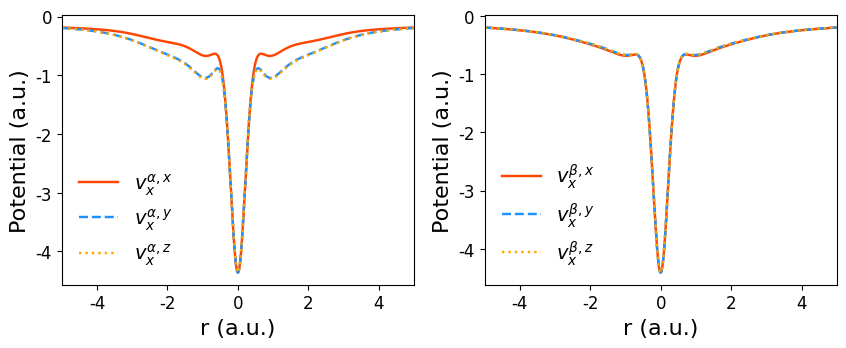

In [28]:
coords_x = gen_coords_1d(-5.0, 5.0, 1000, mode="x")
vcoul_on_grid_x = coulomb_potential_on_grid(mf_oep.pmol, coords_x)
vx_on_grid_a_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_y = gen_coords_1d(-5.0, 5.0, 1000, mode="y")
vcoul_on_grid_y = coulomb_potential_on_grid(mf_oep.pmol, coords_y)
vx_on_grid_a_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_z = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid_z = coulomb_potential_on_grid(mf_oep.pmol, coords_z)
vx_on_grid_a_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords_x[:, 0], vx_on_grid_a_x, color="orangered", label="$v_x^{\\alpha, x}$")
axs[0].plot(coords_y[:, 1], vx_on_grid_a_y, "--", color="dodgerblue", label="$v_{x}^{\\alpha, y}$")
axs[0].plot(coords_z[:, 2], vx_on_grid_a_z, ":", color="orange", label="$v_x^{\\alpha, z}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords_x[:, 0], vx_on_grid_b_x, color="orangered", label="$v_{x}^{\\beta, x}$")
axs[1].plot(coords_y[:, 1], vx_on_grid_b_y, "--", color="dodgerblue", label="$v_{x}^{\\beta, y}$")
axs[1].plot(coords_z[:, 2], vx_on_grid_b_z, ":", color="orange", label="$v_x^{\\beta, z}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.4 Space-symmetrized spin-unrestricted calculation for C atom

In [29]:
# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS, space_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.6e-2)  # thresdold change to converge

ITER        ENERGY               EDIFF
  0    -37.688303049827
  1    -37.688416146203     -0.000113096376
  2    -37.688385087219      0.000031058984
  3    -37.688384464088      0.000000623131
  4    -37.688384167769      0.000000296319
  5    -37.688384043565      0.000000124204
  6    -37.688384045284     -0.000000001718
SCF converged


In [30]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -10.243  -10.305
 2    -0.748   -0.580
 3    -0.424   -0.278
 4    -0.424   -0.278
 5    -0.424   -0.278
 6    -0.119   -0.106
 7    -0.081   -0.071
HOMO:        -0.424    -0.580
LUMO-HOMO:    0.000     0.302


In [31]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 2.0059869


As might be seen, the spherical symmetry of real electronic system is restored and the orbitals in the $p$-shell are three-fold degenerate. However, the symmetry breaking in spin space remains and the orbitals in the $\alpha$ and $\beta$ spin channels and their eigenvalues are different.

Now resulting exchange potentials in both spin channels are spherical.

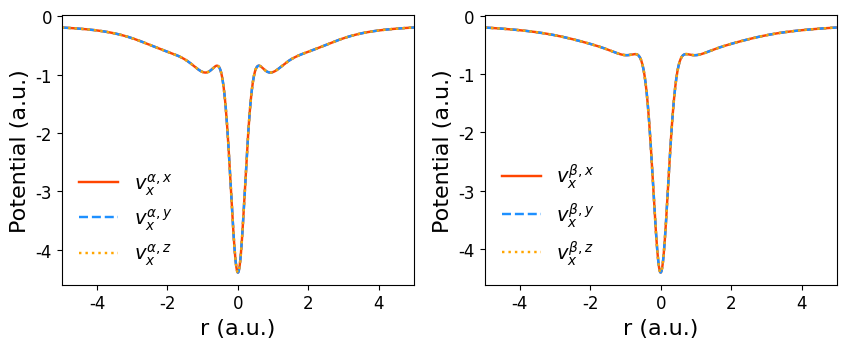

In [32]:
coords_x = gen_coords_1d(-5.0, 5.0, 1000, mode="x")
vcoul_on_grid_x = coulomb_potential_on_grid(mf_oep.pmol, coords_x)
vx_on_grid_a_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_y = gen_coords_1d(-5.0, 5.0, 1000, mode="y")
vcoul_on_grid_y = coulomb_potential_on_grid(mf_oep.pmol, coords_y)
vx_on_grid_a_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_z = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid_z = coulomb_potential_on_grid(mf_oep.pmol, coords_z)
vx_on_grid_a_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords_x[:, 0], vx_on_grid_a_x, color="orangered", label="$v_x^{\\alpha, x}$")
axs[0].plot(coords_y[:, 1], vx_on_grid_a_y, "--", color="dodgerblue", label="$v_{x}^{\\alpha, y}$")
axs[0].plot(coords_z[:, 2], vx_on_grid_a_z, ":", color="orange", label="$v_x^{\\alpha, z}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords_x[:, 0], vx_on_grid_b_x, color="orangered", label="$v_{x}^{\\beta, x}$")
axs[1].plot(coords_y[:, 1], vx_on_grid_b_y, "--", color="dodgerblue", label="$v_{x}^{\\beta, y}$")
axs[1].plot(coords_z[:, 2], vx_on_grid_b_z, ":", color="orange", label="$v_x^{\\beta, z}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.5 Spin-restricted calculation for C atom

In [33]:
# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS, spin_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -37.685577770207
  1    -37.685794018424     -0.000216248216
  2    -37.685792652539      0.000001365884
  3    -37.685797918680     -0.000005266140
  4    -37.685798587234     -0.000000668554
  5    -37.685798584123      0.000000003111
SCF converged


In [34]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -10.304  -10.304
 2    -0.684   -0.684
 3    -0.369   -0.369
 4    -0.369   -0.369
 5    -0.362   -0.362
 6    -0.116   -0.116
 7    -0.081   -0.081
HOMO:        -0.369    -0.684
LUMO-HOMO:    0.006     0.316


In [35]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 2.0000000


In contrast to the spin-unrestricted case, the spin-restricted calculation does not exhibit spin symmetry breaking leading to the same orbital energies in $\alpha$ and $\beta$ spin channels. Space symmetry breaking, however, still appears.

There is only one exchange potential that we plot.

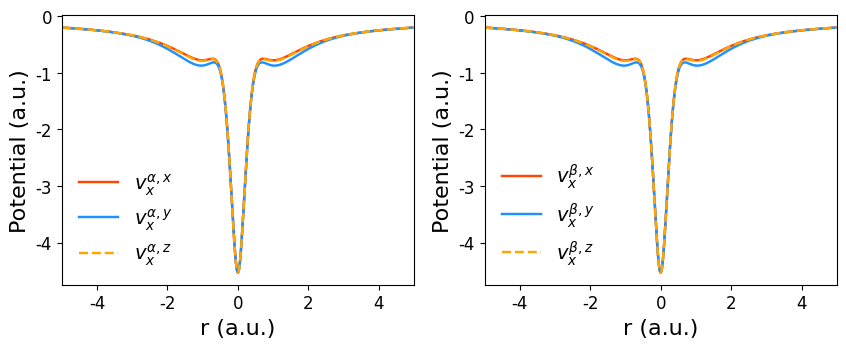

In [36]:
coords_x = gen_coords_1d(-5.0, 5.0, 1000, mode="x")
vcoul_on_grid_x = coulomb_potential_on_grid(mf_oep.pmol, coords_x)
vx_on_grid_a_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_y = gen_coords_1d(-5.0, 5.0, 1000, mode="y")
vcoul_on_grid_y = coulomb_potential_on_grid(mf_oep.pmol, coords_y)
vx_on_grid_a_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_z = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid_z = coulomb_potential_on_grid(mf_oep.pmol, coords_z)
vx_on_grid_a_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords_x[:, 0], vx_on_grid_a_x, color="orangered", label="$v_x^{\\alpha, x}$")
axs[0].plot(coords_y[:, 1], vx_on_grid_a_y, color="dodgerblue", label="$v_{x}^{\\alpha, y}$")
axs[0].plot(coords_z[:, 2], vx_on_grid_a_z, "--", color="orange", label="$v_x^{\\alpha, z}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords_x[:, 0], vx_on_grid_b_x, color="orangered", label="$v_{x}^{\\beta, x}$")
axs[1].plot(coords_y[:, 1], vx_on_grid_b_y, color="dodgerblue", label="$v_{x}^{\\beta, y}$")
axs[1].plot(coords_z[:, 2], vx_on_grid_b_z, "--", color="orange", label="$v_x^{\\beta, z}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.6 Fully-symmetrized calculation for C atom

To restore full symmetry of real electronic system, we can use spin-restricted, i.e. spin-symmetrized, EXX method with space-symmetrization.

In [37]:
# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS, spin_sym=True, space_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -37.685674667062
  1    -37.685603121661      0.000071545401
  2    -37.685649416833     -0.000046295172
  3    -37.685640796926      0.000008619907
  4    -37.685640795381      0.000000001545
SCF converged


In [38]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -10.321  -10.321
 2    -0.700   -0.700
 3    -0.381   -0.381
 4    -0.381   -0.381
 5    -0.381   -0.381
 6    -0.118   -0.118
 7    -0.081   -0.081
HOMO:        -0.381    -0.700
LUMO-HOMO:    0.000     0.319


In [39]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 2.0000000


The full symmetry of the real electronic system is restored. The orbitals in the $p$-shell exhibit three-fold degeneracy and the same orbitals result for the two spin channels.

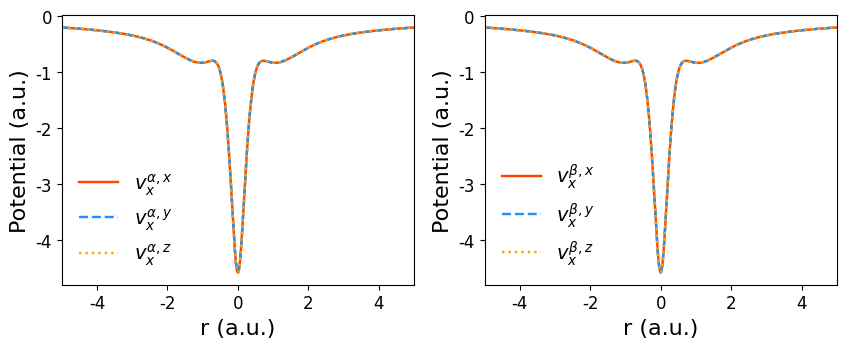

In [40]:
coords_x = gen_coords_1d(-5.0, 5.0, 1000, mode="x")
vcoul_on_grid_x = coulomb_potential_on_grid(mf_oep.pmol, coords_x)
vx_on_grid_a_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_x = vcoul_on_grid_x @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_y = gen_coords_1d(-5.0, 5.0, 1000, mode="y")
vcoul_on_grid_y = coulomb_potential_on_grid(mf_oep.pmol, coords_y)
vx_on_grid_a_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_y = vcoul_on_grid_y @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_z = gen_coords_1d(-5.0, 5.0, 1000)
vcoul_on_grid_z = coulomb_potential_on_grid(mf_oep.pmol, coords_z)
vx_on_grid_a_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_z = vcoul_on_grid_z @ (mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords_x[:, 0], vx_on_grid_a_x, color="orangered", label="$v_x^{\\alpha, x}$")
axs[0].plot(coords_y[:, 1], vx_on_grid_a_y, "--", color="dodgerblue", label="$v_{x}^{\\alpha, y}$")
axs[0].plot(coords_z[:, 2], vx_on_grid_a_z, ":", color="orange", label="$v_x^{\\alpha, z}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords_x[:, 0], vx_on_grid_b_x, color="orangered", label="$v_{x}^{\\beta, x}$")
axs[1].plot(coords_y[:, 1], vx_on_grid_b_y, "--", color="dodgerblue", label="$v_{x}^{\\beta, y}$")
axs[1].plot(coords_z[:, 2], vx_on_grid_b_z, ":", color="orange", label="$v_x^{\\beta, z}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

Finally, we can verify that effect of symmetrizations make EXX total energy higher:

In [41]:
print(bold_text("Non-symmetrized, i.e. spin-unrestricted"))

# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS, spin_sym=False, space_sym=False)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

print()
print(bold_text("Space-symmetrized, i.e. spin-unrestricted with space-symmetrization"))

# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS, spin_sym=False, space_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.6e-2)

print()
print(bold_text("Spin-symmetrized, i.e. spin-restricted"))

# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS, spin_sym=True, space_sym=False)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

print()
print(bold_text("Fully-symmetrized, i.e. space- and spin-symmetrized"))

# run Hartree-Fock calculation
mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

# run EXX-OEP calculation
mf_oep = OSEXXOEP(mf, OEP_BASIS, spin_sym=True, space_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

Non-symmetrized, i.e. spin-unrestricted
ITER        ENERGY               EDIFF
  0    -37.691537898514
  1    -37.691556951004     -0.000019052490
  2    -37.691556748973      0.000000202030
  3    -37.691556834537     -0.000000085563
  4    -37.691556840407     -0.000000005870
SCF converged

Space-symmetrized, i.e. spin-unrestricted with space-symmetrization
ITER        ENERGY               EDIFF
  0    -37.688303049827
  1    -37.688416149654     -0.000113099828
  2    -37.688385303661      0.000030845993
  3    -37.688384458063      0.000000845598
  4    -37.688384172222      0.000000285841
  5    -37.688384045712      0.000000126510
  6    -37.688384045560      0.000000000152
SCF converged

Spin-symmetrized, i.e. spin-restricted
ITER        ENERGY               EDIFF
  0    -37.685577770207
  1    -37.685794018424     -0.000216248216
  2    -37.685792652539      0.000001365884
  3    -37.685797918680     -0.000005266141
  4    -37.685798587234     -0.000000668554
  5    -37.6857985

## 4. Concluding remarks
In this tutorial, we explored exact-exchange optimized effective potential calculations for closed- and open-shell systems.

For open-shell systems, in addition to the standard spin-unrestricted EXX-OEP method, we looked at the spin-restricted EXX method, which preserves the correct spin symmetry of a real electronic system. For both spin-unrestricted and spin-restricted EXX-OEP methods, we also performed calculations with additional space-symmetrization, which forces the KS system to have the correct spatial symmetry of a real electronic system.

We considered an option to enforce an additional exact condition for the exchange potential, the so-called HOMO condition.

As a post-processing of calculations, we accessed and printed orbital energies and explored how to plot the resulting exchange potential and its individual contributions.

---

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/PyOEP/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/PyOEP/)  If you found this tutorial helpful, consider ⭐-ing the repository.